# VEP DNA Pipeline

## Install core dependencies

- Each model run in the VEP DNA pipeline requires slightly different dependencies. 
- While `vep_pipeline` can theoretically run multiple models in a single python session, it's more practical to maintain
separate conda environments and activate the model's respective environemnt before running `vep_pipeline` on that model.
- See the folder *conda/* for different conda env yamls for each model. To install, just run conda env `create -f <path/to/file.yml`>.


Nevertheless, here are the core dependencies that the pipeline always needs to run `vep_pipeline` (if the conda yaml does not already install them for you). 

The following examples use only chromosome 22 in the Geuvadis collection from 1000 Genomes Project (452 individals).

### Troubleshooting
- If you're noticing that only a limited number of your sites (e.g. ClinVar variants) are actually generating VEPs, this may be due to the fact that your *.gvi* index file for your *.vcf* is outdated. Correct this by finding the folder where your VCFs are stored (`~/projects/1000_Genomes_on_GRCh38/vcf/` by default) and deleting any *.gvi* files: e.g. `rm ~/projects/1000_Genomes_on_GRCh38/vcf/*.gvi`

In [ ]:
# To install GenVarLoader
!conda install bioconda::pgenlib -y
!pip install git+https://github.com/mcvickerlab/GenVarLoader.git
# !pip install --no-deps git+https://github.com/mcvickerlab/GenVarLoader.git --force-reinstall 

# To install xarray
!conda install conda-forge::xarray conda-forge::zarr -y

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

# Set environment variable to suppress datetime warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

## Prepare data

### Download population data

In [2]:
# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
)


### Create BED file

This BED file is based on the coordinates of the UTR variants we're planning on injecting, surrounded by 500kb windows.

In [3]:
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz") 
# bed = gvl.read_bedlike(bed_path)

print(bed.shape)
bed.head()

(13771, 25)


chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i64,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",2,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""


### Create GVL database

In [4]:
ds_path = TemporaryDirectory(suffix=".gvl").name

bed_chrom = bed.filter(pl.col('chrom').str.replace("chr","")=='22')
force = False
if not os.path.exists(ds_path) or force:
    gvl.write(
        path=ds_path,
        bed=gvl.with_length(bed_chrom[:20], 2**18),  # change region length to 131,072 bp
        variants=variants,
        overwrite=True,
    )

2025-05-23 20:09:39.327 | INFO     | genvarloader._dataset._write:write:75 - Writing dataset to /tmp/tmpq_n9fbkr.gvl
2025-05-23 20:09:39.333 | INFO     | genoray._pgen:_read_index:1078 - Loading genoray index.


2025-05-23 20:09:39.732 | INFO     | genvarloader._dataset._write:write:147 - Using 451 samples.
2025-05-23 20:09:39.733 | INFO     | genvarloader._dataset._write:write:153 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

2025-05-23 20:09:40.976 | INFO     | genvarloader._dataset._write:write:177 - Finished writing.


### Import GVL database

In [5]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes") 
    .with_len(2**18)
)

2025-05-23 20:09:41.401 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.


2025-05-23 20:09:41.422 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 20:09:41.442 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /tmp/tmpq_n9fbkr.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



In [6]:
ds_ref = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("reference") 
    .with_len(2**18)
)

2025-05-23 20:09:42.225 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 20:09:42.246 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.


2025-05-23 20:09:42.268 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /tmp/tmpq_n9fbkr.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



### Create DatasetWithSites

In [7]:
# Convert BED to sites
sites = cv.bed_to_sites(bed) 

sites_chrom = sites.filter(pl.col("CHROM").str.replace("chr","")=="22")

# Import sites_ds
site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
site_ds_ref = gvl.DatasetWithSites(ds_ref, sites_chrom)

site_ds

## Run VEP

Initialize xarray Dataset.

In [207]:
# Create path for results file
results_dir = os.path.join(os.path.expanduser('~'), 
                           "projects","data")
cohort = "1000_Genomes_on_GRCh38"
variant_set = "clinvar_utr_snv"
chrom = "chr22"
xr_ds_path = os.path.join(results_dir,
                         cohort,
                         variant_set,
                         f"{chrom}.zarr")
print(xr_ds_path)
os.makedirs(os.path.dirname(xr_ds_path), exist_ok=True)

# Initialize or load the dataset
all_models = ["flashzoi", "evo2_7b", "spliceai_mm"]
xr_ds = vp.init_or_load_xarray_dataset(
    xr_ds_path=xr_ds_path,
    all_models=all_models, 
    site_ds=site_ds, 
    force=True
)
xr_ds

/home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
Initializing new Dataset at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


Initializing DataArrays:   0%|          | 0/3 [00:00<?, ?it/s]

Creating xarray Dataset with 3 model(s)
Saving xarray Dataset to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
xarray Dataset saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `<U15` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `<U27` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `<U9` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.py:4257: Us

<xarray.Dataset> Size: 6MB
Dimensions:      (site: 20, sample: 453, ploid: 2, slot: 13)
Coordinates:
  * site         (site) <U27 2kB 'chr22:17113326-17113327_A_G' ... 'chr22:171...
  * sample       (sample) <U9 16kB 'REF' 'consensus' ... 'NA20826' 'NA20828'
  * ploid        (ploid) <U1 8B '0' '1'
  * slot         (slot) <U15 780B 'VEP' 'VEP_acceptor' ... 'timestamp'
Data variables:
    flashzoi     (site, sample, ploid, slot) float64 2MB nan nan nan ... nan nan
    evo2_7b      (site, sample, ploid, slot) float64 2MB nan nan nan ... nan nan
    spliceai_mm  (site, sample, ploid, slot) float64 2MB nan nan nan ... nan nan

Populate the `xarray` dataset using the steamlined `vep_pipeline` function.

In [216]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")

xr_ds_path=" /tmp/vep_pipeline_a7303246.zarr"
xr_ds = vp.vep_pipeline(site_ds=site_ds, 
                           xr_ds_path=xr_ds_path,
                           run_models=["flashzoi"],  
                           max_seqs_per_batch=30,
                           
                           verbose=1,
                           device="cuda:3",
                           # force=2,
                           limit_samples=50,
                           limit_sites=5
                           )

2025-05-23 22:50:49.615 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 22:50:49.637 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 22:50:49.658 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /tmp/tmpq_n9fbkr.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



Dataset will be saved to  /tmp/vep_pipeline_a7303246.zarr
Loading existing results from  /tmp/vep_pipeline_a7303246.zarr
xarray Dataset dimensions: FrozenMappingWarningOnValuesAccess({'site': 20, 'sample': 452, 'ploid': 2, 'slot': 14})
Using reference genome from /home/schilder/.cache/pooch/edfb24b9fee5f1060c26e092a696e447-Homo_sapiens.GRCh38.dna.chromosome.22.fa.bgz


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/20 [00:00<?, ?it/s]

Iterating over sample batches (452 samples total):   0%|          | 0/31 [00:00<?, ?it/s]

Iterating over sample batches (452 samples total):   0%|          | 0/31 [00:00<?, ?it/s]

Iterating over sample batches (452 samples total):   0%|          | 0/31 [00:00<?, ?it/s]

Iterating over sample batches (452 samples total):   0%|          | 0/31 [00:00<?, ?it/s]

Iterating over sample batches (452 samples total):   0%|          | 0/31 [00:00<?, ?it/s]

Get non-null subset of VEP results 

In [217]:
vep_df = vp.load_vep_results(xr_ds, dropna_subset=["flashzoi"])
vep_df.head()

After filtering:
 - rows: 26028
 - sites: 5
 - samples: 452


,site,sample,ploid,slot,flashzoi,evo2_40b,spliceai_mm,evo2_7b,evo2_7b_base,evo2_40b_base,dnabert2,spliceai
3,chr22:17110199-17110200_G_A,REF,0,delta_abs_mean,0.000341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chr22:17110199-17110200_G_A,REF,0,delta_max_max,0.285123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,chr22:17110199-17110200_G_A,REF,0,delta_mean,-0.000119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,chr22:17110199-17110200_G_A,REF,0,delta_pow2_mean,0.000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,chr22:17110199-17110200_G_A,REF,0,len_seq_mut,262144.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
va.estimate_runtime(vep_df,
                     total_sites=bed["name"].n_unique(),
                     model_name="flashzoi",
                     time_col="time_total",
                     n_gpus=1)

0.38 minutes per site
Number of days it should take to run all 13771 sites genome-wide:
3.63


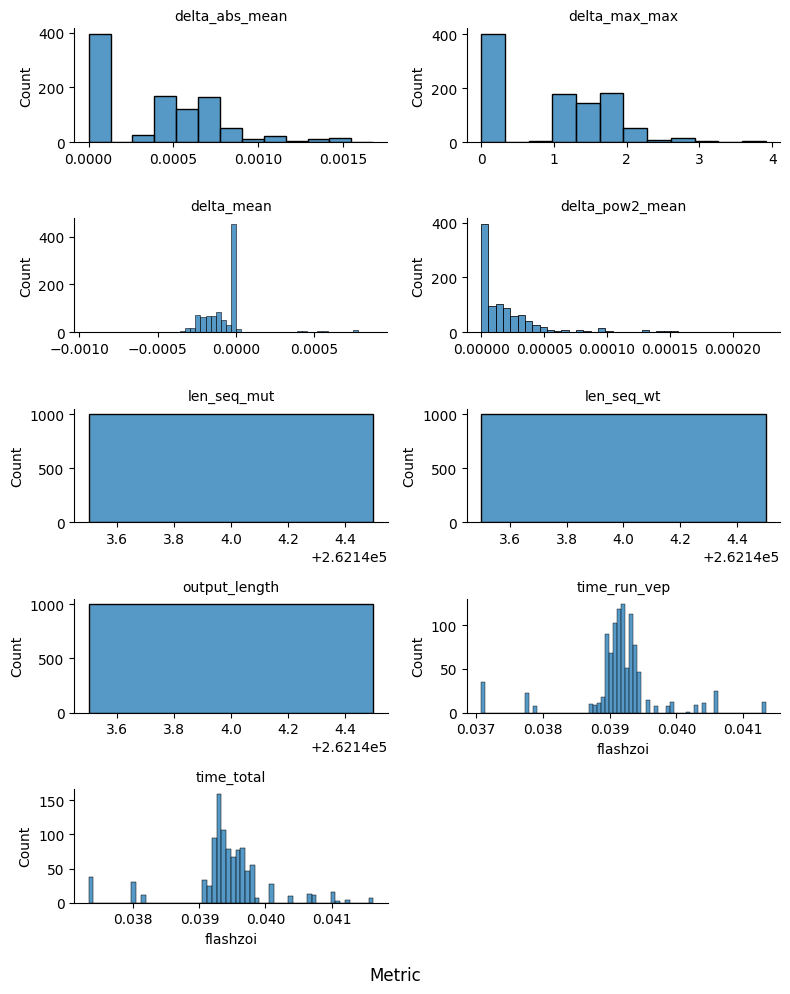

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.groupby("slot").sample(1000, replace=True).sort_values("slot"),
                  col="slot",  # Changed from row to col
                  col_wrap=2,  # Added col_wrap to wrap facets
                  height=2, 
                  aspect=2, 
                  margin_titles=True,
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="flashzoi")
g.set_titles("{col_name}")
g.fig.supxlabel("Metric")
plt.tight_layout()

## Run VEP pipeline for full 1KG dataset

Here we extend the `vep_pipeline` to run on all 2.5K+ individuals in the low-coverage WGS cohort.

This includes all chromosomes (not just chromosome 22).

In [2]:
import src.onekg as og
cohort = "1000_Genomes_on_GRCh38"
variant_set = "clinvar_utr_snv"

# Chrom-specific fasta references: 
# https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz

# Merged fasta reference
# https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
reference = pooch.retrieve(
    url=og.get_ftp_dict()[cohort]['ref'],
    known_hash=None,
    progressbar=True
)

manifest = og.list_remote_vcf(key=cohort)
chroms = manifest['chrom'].unique().tolist()
chroms.reverse()

# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

In [ ]:
print(site_ds.rows.shape)
print(site_ds.n_rows)
print(site_ds.sites.shape)

In [ ]:
# Steamlined version

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")
warnings.filterwarnings("ignore", category=UserWarning, message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import src.vep_pipeline as vp
import src.clinvar as cv
import polars as pl

import torch
torch.set_default_device("cuda:2")

# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")
 
# # Run VEP pipeline for 1KG dataset (all chromosomes)
xr_ds = vp.vep_pipeline_onekg(bed=bed, 
                            #   limit_chroms=1,
                            #   limit_samples=50,
                            #   limit_sites=2,
                              # force_gvl=True,
                              # force_vep=2,
                             
                             variant_set="clinvar_utr_snv",
                              # site_filters={"CLNREVSTAT_score":3},
                              run_models=["flashzoi"])

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.


Iterating over chromosomes:   0%|          | 0/1 [00:00<?, ?it/s]


2025-06-04 12:57:05.219 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-06-04 12:57:05.260 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-06-04 12:57:05.264 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test_tmp/chrX.gvl
Is subset: False
# of regions: 438
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None

2025-06-04 12:57:05.336 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-06-04 12:57:05.376 | INFO     | genvarloader._dataset._reconstruct:fr

Dataset will be saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test_tmp/chrX.zarr
Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv_test_tmp/chrX.zarr
xarray Dataset dimensions: FrozenMappingWarningOnValuesAccess({'site': 438, 'sample': 2549, 'ploid': 2, 'slot': 14})
Using reference genome from /home/schilder/.cache/pooch/296ca04ba1df562072adc4c76f64cfb9-GRCh38_full_analysis_set_plus_decoy_hla.fa


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/438 [00:00<?, ?it/s]

Iterating over sample batches (2549 samples total):   0%|          | 0/170 [00:00<?, ?it/s]

Iterating over sample batches (2549 samples total):   0%|          | 0/170 [00:00<?, ?it/s]

In [6]:
vep_df = vp.load_vep_results(xr_ds, 
                             dropna_subset=["flashzoi"])

vep_df.head()

Contents of xarray after filtering [filled values / total values]:
 - rows: 1800
 - sites: 2 / 438
 - samples: 45 / 2549
 - ploid: 2 / 2
 - slots: 10 / 14


,site,sample,ploid,slot,evo2_7b_base,spliceai,evo2_40b,flashzoi,dnabert2,evo2_7b,spliceai_mm,evo2_40b_base
5138784,chrX:630879-630880_G_A,REF,0,COVR,NaN,NaN,NaN,1.118504,NaN,NaN,NaN,NaN
5138788,chrX:630879-630880_G_A,REF,0,delta_abs_mean,NaN,NaN,NaN,0.000790,NaN,NaN,NaN,NaN
5138789,chrX:630879-630880_G_A,REF,0,delta_max_max,NaN,NaN,NaN,3.624626,NaN,NaN,NaN,NaN
5138790,chrX:630879-630880_G_A,REF,0,delta_mean,NaN,NaN,NaN,0.000242,NaN,NaN,NaN,NaN
5138791,chrX:630879-630880_G_A,REF,0,delta_pow2_mean,NaN,NaN,NaN,0.000045,NaN,NaN,NaN,NaN


In [7]:
vep_df

,site,sample,ploid,slot,evo2_7b_base,spliceai,evo2_40b,flashzoi,dnabert2,evo2_7b,spliceai_mm,evo2_40b_base
5138784,chrX:630879-630880_G_A,REF,0,COVR,NaN,NaN,NaN,1.118504,NaN,NaN,NaN,NaN
5138788,chrX:630879-630880_G_A,REF,0,delta_abs_mean,NaN,NaN,NaN,0.000790,NaN,NaN,NaN,NaN
5138789,chrX:630879-630880_G_A,REF,0,delta_max_max,NaN,NaN,NaN,3.624626,NaN,NaN,NaN,NaN
5138790,chrX:630879-630880_G_A,REF,0,delta_mean,NaN,NaN,NaN,0.000242,NaN,NaN,NaN,NaN
5138791,chrX:630879-630880_G_A,REF,0,delta_pow2_mean,NaN,NaN,NaN,0.000045,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
15346234,chrX:658943-658944_T_G,HG00141,1,len_seq_mut,NaN,NaN,NaN,250000.000000,NaN,NaN,NaN,NaN
15346235,chrX:658943-658944_T_G,HG00141,1,len_seq_wt,NaN,NaN,NaN,250000.000000,NaN,NaN,NaN,NaN
15346236,chrX:658943-658944_T_G,HG00141,1,output_length,NaN,NaN,NaN,250000.000000,NaN,NaN,NaN,NaN
15346237,chrX:658943-658944_T_G,HG00141,1,time_run_vep,NaN,NaN,NaN,0.040331,NaN,NaN,NaN,NaN


## Get the unique haplotypes

In [33]:
print(site_ds.dataset._seqs.genotypes.shape)
site_ds.dataset._seqs.genotypes

(20, 451, 2)


[[[[120658, 120697, 120718, 120747, ..., 127557, 127559, 127571], ...], ...],
 [[[120658, 120697, 120718, 120747, ..., 127557, 127559, 127571], ...], ...],
 [[[121315, 121328, 121388, 121397, ..., 128145, 128175, 128180], ...], ...],
 ...,
 [[[121388, 121397, 121401, 121446, ..., 128456, 128464, 128471], ...], ...]]

In [3]:
import uuid, os
xr_ds_path = os.path.join("tmp", f"vep_pipeline_{uuid.uuid4().hex[:8]}.zarr")
xr_ds_path

'tmp/vep_pipeline_4ffdd3e0.zarr'

In [34]:
site_ds.dataset._seqs.genotypes[0,0,0]

array([120658, 120697, 120718, 120747, 120772, 120811, 120815, 120852,
       120863, 120864, 120867, 120912, 120951, 120964, 120972, 121000,
       121026, 121104, 121106, 121130, 121166, 121185, 121196, 121199,
       121211, 121215, 121232, 121253, 121254, 121315, 121328, 121388,
       121397, 121401, 121446, 121476, 121477, 121481, 121538, 121593,
       121613, 121658, 121730, 121749, 121750, 121798, 121852, 121863,
       121882, 121900, 121923, 121926, 121939, 121940, 121941, 121959,
       122049, 122052, 122054, 122056, 122057, 122064, 122087, 122101,
       122104, 122123, 122127, 122137, 122164, 122169, 122175, 122178,
       122211, 122222, 122234, 122249, 122263, 122305, 122318, 122327,
       122328, 122359, 122364, 122385, 122391, 122400, 122404, 122415,
       122417, 122432, 122433, 122437, 122439, 122447, 122458, 122477,
       122483, 122490, 122493, 122505, 122532, 122539, 122555, 122565,
       122566, 122568, 122578, 122581, 122582, 122583, 122593, 122600,
      

haplotype = chr:start-end:variants --> hash

In [41]:
site_ds.dataset._seqs.genotypes[]

[[[[120658, 120697, 120718, 120747, ..., 127557, 127559, 127571], ...], ...],
 [[[120658, 120697, 120718, 120747, ..., 127557, 127559, 127571], ...], ...],
 [[[121315, 121328, 121388, 121397, ..., 128145, 128175, 128180], ...], ...],
 ...,
 [[[121388, 121397, 121401, 121446, ..., 128456, 128464, 128471], ...], ...]]

In [42]:
site_ds.dataset._seqs.variants

_Variants(v_starts=array([10519264, 10519275, 10519388, ..., 50807842, 50807849, 50807849],
      shape=(1065095,)), ilens=array([ -1,   0,   0, ...,   0,   1, -24], shape=(1065095,), dtype=int32), alts=RaggedAlleles(data=array([b'C', b'C', b'C', ..., b'A', b'G', b'A'],
      shape=(1372519,), dtype='|S1'), shape=(1065095,), maybe_offsets=array([      0,       1,       2, ..., 1372516, 1372518, 1372519],
      shape=(1065096,)), maybe_lengths=None))

In [ ]:
import awkward as ak
import numba as nb
import numpy as np
from attrs import define
from seqpro._ragged import Ragged
from genvarloader._dataset._reconstruct import Haps, V_IDX_TYPE
from genvarloader._dataset._impl import Dataset


@define
class UniqueInfo:
    """Class to store unique genotypes."""

    # sample, ploidy => ds[region_idx, sample_idx][ploid_idx] (ploidy length) => unique haplotype sequence
    first_idxs: Ragged[np.void]
    """First haplotype indices. Shape: (n_regions, ~n_unique)"""
    inverse_idxs: ak.Array  # total elements = regions * samples * ploidy
    """Inverse indices. Shape: (n_regions, ~n_unique, ~n_haps)"""
    counts: Ragged[np.uint32]
    """Counts. Shape: (n_regions, ~n_unique)"""

    @property
    def n_regions(self) -> int:
        """Number of regions."""
        return self.first_idxs.shape[0]

    @property
    def n_unique(self):
        """Number of unique genotypes."""
        return self.first_idxs.lengths


def unique(dataset: Dataset) -> UniqueInfo:
    if not isinstance(dataset._seqs, Haps):
        raise ValueError(
            "Dataset must have genotypes/haplotypes to compute unique haplotype information."
        )

    genos = dataset._seqs.genotypes
    regions = dataset._full_regions
    out_len = dataset.output_length
    first_idxs, inverse_idxs, counts = _unique_genotypes(
        genos.data, genos.offsets, regions, out_len
    )


@nb.njit(nogil=True, cache=True)
def _unique_genotypes(v_idxs, v_offsets, regions, out_len): 
    pass

## GVL to MSA

Convert a GVL database of haplotype sequences to a multiple sequence alignment.

In [292]:
region_idx = 0
sample_idx = range(451)

ref_coords = GVL.stack_ploidy(site_ds[region_idx, ][0].ref_coords[sample_idx,])
seq_arr = GVL.stack_ploidy(ds.subset_to(samples=sample_idx)[region_idx,])
msa = GVL.create_msa(ref_coords, seq_arr)

MSA for 902 sequences done 0.19 seconds


In [302]:
GVL.preview_msa(msa[:,:10000])

CCCAGTGTCACCGGGTCGATCGGACCGGTCGCGGCGGGTCGGCTACCTCCACCAACGCAAATCAAAAAAAATGCTCCGGTGGCGCACCGCTAGTTCGTCGTTGCATAAAGATACTTCTCCGA
GCCAGTGTCACCGGGTCGATCGGGCCGGTCGCGGTGGGTCGGCTACCTTCACCAACGCAAGTCAAAAAAAATGCTCCGGTGGCATACCGCTAGTTCGTCGTTACATATTGGTACTTCTCCGA
CTCAGTGTCACCGGGTCGATCGGACCGGTCGCGGCGGGTC-GCTACCTCCACCAACGCAGGTC---------GCTCCGGTGGCGCGCCGCTAGTTCGTCGCTGCATAATGGTACTCCTCCGA
CCCATTGTCAGCGGGTCGATCGGGCCGGTCGCGGCGGGTCGGCTACCTCCACCAACGCAGGTAAAAAAAAATGCTCCGGCGGCGCACCGCCAGCTCGTCACTGCATAATGGTACTTCTCCGA
CCCAGTGTCACCGGGTCGATCGTGCCGGTCGCGGCCGGTCGGCTACCTCCACCAACGCAGGTCAAAAA----GCTCCGGTGGCGCAGCGCTCGTTCGTCGCTGTACATTGGTACTTCTCCGA
CCCATTGTCAGCGGGTCGATCGGGCCGGTCGCGGCGGGTCGGCTACCTCCACCAACGCAGGTAAAAAAAAATGCTCCGGCGGCGCACCGCCAGCTCGTCACTGCATAATGGTACTTCTCCGA
CCCAGTGTCACCGGGTCGATCGGACCGGTCGCGGCGGGTCGGCTACCTCCACCAACGCAAATCAAAAAAAATGCTCCGGTGGCGCACCGCTAGTTCGTCGTTGCATAAAGATACTTCTCCGA
CCCATTGTCAGCGGGTCGATCGGGCCGGTCGCGGCGGGTCGGCTACCTCCACCAACGCAGGTAAAAAAAAATGCTCCGGCGGCGCACCGCCAGCTCGTCACTGCATAATGGTACTTCTCCGA
CCCAGTGTCACCGGGT

### Generate a consensus sequence from the MSA

In [ ]:
consensus_seq = GVL.create_consensus_seq(msa, as_str=True)
consensus_seq